# 01 · YOLO Pose + MediaPipe FaceMesh — multi-GPU / CPU adaptive

In [16]:
'''
!pip install ultralytics opencv-python-headless pandas numpy torch torchvision
!pip install mediapipe==0.10.13
'''

'\n!pip install ultralytics opencv-python-headless pandas numpy torch torchvision\n!pip install mediapipe==0.10.13\n'

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import mediapipe as mp
import multiprocessing as mp_proc
from pathlib import Path
from ultralytics import YOLO


In [18]:
# ── paths ─────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

BASE       = Path("/content/drive/MyDrive/CREATE Lab/video_agent360")
INPUT_DIR  = BASE / "autocrop_out"
OUTPUT_DIR = BASE / "features_yolo01"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = Path("/content/yolov8n-pose.pt")

# ── environment detection ──────────────────────────────────────────────────────
N_GPUS     = torch.cuda.device_count()
BATCH_SIZE = 8

if N_GPUS == 0:
    DEVICES   = ["cpu"]
    N_WORKERS = 1
    print("no GPU found — running single-process on CPU")
elif N_GPUS == 1:
    DEVICES   = ["cuda:0"]
    N_WORKERS = 1
    print(f"1 GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICES   = [f"cuda:{i}" for i in range(N_GPUS)]
    N_WORKERS = N_GPUS
    print(f"{N_GPUS} GPUs:")
    for i in range(N_GPUS):
        vram = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"  cuda:{i}  {torch.cuda.get_device_name(i)}  {vram:.1f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1 GPU: Tesla T4


In [19]:
# YOLO pose keypoint indices (COCO 17-point skeleton)
KP_NOSE = 0
KP_L_EYE, KP_R_EYE   = 1, 2
KP_L_EAR, KP_R_EAR   = 3, 4
KP_L_SHOULDER, KP_R_SHOULDER = 5, 6
KP_L_ELBOW,   KP_R_ELBOW    = 7, 8
KP_L_WRIST,   KP_R_WRIST    = 9, 10

# MediaPipe FaceMesh landmark indices used for expression features
MP_LEFT_MOUTH  = 61
MP_RIGHT_MOUTH = 291
MP_UPPER_LIP   = 13
MP_LOWER_LIP   = 14
MP_LEFT_CHEEK  = 234
MP_RIGHT_CHEEK = 454

FACE_PAD = 0.25   # padding around body bbox when cropping face region


In [20]:
def extract_face_features(face_mesh, frame: np.ndarray, bbox_xyxy: np.ndarray) -> dict:
    """
    Crop the face region from frame using YOLO body bbox, run MediaPipe FaceMesh,
    return smile_score and mouth_open_score (both NaN on failure).

    face_mesh is passed in so each worker reuses its own instance rather than
    creating a new one per frame.
    """
    h, w   = frame.shape[:2]
    x1, y1, x2, y2 = bbox_xyxy.astype(int)

    pad_x = int((x2 - x1) * FACE_PAD)
    pad_y = int((y2 - y1) * FACE_PAD)
    crop  = frame[max(0, y1 - pad_y):min(h, y2 + pad_y),
                  max(0, x1 - pad_x):min(w, x2 + pad_x)]

    if crop.size == 0:
        return {"smile_score": np.nan, "mouth_open_score": np.nan}

    result = face_mesh.process(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    if not result.multi_face_landmarks:
        return {"smile_score": np.nan, "mouth_open_score": np.nan}

    lm  = result.multi_face_landmarks[0].landmark
    ch, cw = crop.shape[:2]

    def pt(idx):
        return np.array([lm[idx].x * cw, lm[idx].y * ch])

    mouth_width = np.linalg.norm(pt(MP_RIGHT_MOUTH) - pt(MP_LEFT_MOUTH))
    face_width  = np.linalg.norm(pt(MP_RIGHT_CHEEK) - pt(MP_LEFT_CHEEK))
    mouth_open  = np.linalg.norm(pt(MP_LOWER_LIP)   - pt(MP_UPPER_LIP))

    if face_width == 0:
        return {"smile_score": np.nan, "mouth_open_score": np.nan}

    return {
        "smile_score":      float(mouth_width / face_width),
        "mouth_open_score": float(mouth_open  / face_width),
    }


In [21]:
def apply_behavior_logic(df: pd.DataFrame, fps: float = 30.0) -> pd.DataFrame:
    df = df.copy()

    for col in ["yaw_proxy", "pitch_proxy", "smile_score", "mouth_open_score",
                "left_wrist_x", "left_wrist_y", "right_wrist_x", "right_wrist_y",
                "left_wrist_speed", "right_wrist_speed"]:
        if col in df.columns:
            df[col] = df[col].interpolate(limit_direction="both")

    df["look_down_flag"]  = df["pitch_proxy"] > 0.06
    df["look_up_flag"]    = df["pitch_proxy"] < -0.02
    df["turn_left_flag"]  = df["yaw_proxy"]   < -0.05
    df["turn_right_flag"] = df["yaw_proxy"]   >  0.05

    win = max(5, int(fps * 0.5))
    df["pitch_range"]       = (df["pitch_proxy"].rolling(win, min_periods=3).max()
                             - df["pitch_proxy"].rolling(win, min_periods=3).min())
    df["head_nodding_flag"] = df["pitch_range"] > 0.04

    df["smiling_flag"]       = df["smile_score"]      > 0.42
    df["speaking_like_flag"] = df["mouth_open_score"] > 0.08

    df["hand_near_bottom"] = (df["left_wrist_y"]  > 0.65) | (df["right_wrist_y"] > 0.65)
    df["hand_moving"]      = (df["left_wrist_speed"] > 0.02) | (df["right_wrist_speed"] > 0.02)
    df["take_notes_flag"]  = df["look_down_flag"] & df["hand_near_bottom"] & df["hand_moving"]

    df["engagement_score"] = 0.0
    df.loc[df["face_detected"] == 1,  "engagement_score"] += 0.20
    df.loc[df["pose_detected"] == 1,  "engagement_score"] += 0.10
    df.loc[df["head_nodding_flag"],   "engagement_score"] += 0.20
    df.loc[df["speaking_like_flag"],  "engagement_score"] += 0.20
    df.loc[df["smiling_flag"],        "engagement_score"] += 0.10
    df.loc[df["look_down_flag"],      "engagement_score"] -= 0.10
    df.loc[df["take_notes_flag"],     "engagement_score"] += 0.10
    df["engagement_score"] = df["engagement_score"].clip(0, 1)

    return df


In [22]:
def process_single_video(video_path: Path, device: str, model: YOLO, face_mesh) -> str:
    """
    Process one video on the given device.
    model and face_mesh are passed in so workers can reuse them across videos
    rather than reloading from disk each time.
    """
    participant_id = video_path.stem
    output_csv     = OUTPUT_DIR / f"{participant_id}_features.csv"

    if output_csv.exists():
        return f"skip (done): {participant_id}"

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return f"error: cannot open {video_path}"

    fps     = cap.get(cv2.CAP_PROP_FPS) or 30.0
    records = []
    batch_frames, batch_raw, batch_idx = [], [], []
    frame_idx = 0
    prev_lw = prev_rw = prev_t = None

    def flush_batch(frames, raw_frames, indices):
        nonlocal prev_lw, prev_rw, prev_t
        results_list = model(frames, device=device, verbose=False, conf=0.5,
                             half=False)
        batch_records = []

        for res, raw_frame, fidx in zip(results_list, raw_frames, indices):
            t   = fidx / fps
            row = {
                "frame_idx": fidx, "t": float(t),
                "face_detected": 0, "pose_detected": 0,
                "yaw_proxy": np.nan,  "pitch_proxy": np.nan,
                "smile_score": np.nan, "mouth_open_score": np.nan,
                "left_wrist_x": np.nan,    "left_wrist_y": np.nan,
                "right_wrist_x": np.nan,   "right_wrist_y": np.nan,
                "left_wrist_vis": np.nan,  "right_wrist_vis": np.nan,
                "left_elbow_y": np.nan,    "right_elbow_y": np.nan,
                "left_shoulder_y": np.nan, "right_shoulder_y": np.nan,
                "left_wrist_speed": np.nan,"right_wrist_speed": np.nan,
            }

            if res.keypoints is None or len(res.keypoints) == 0:
                batch_records.append(row)
                continue

            row["pose_detected"] = 1
            row["face_detected"] = 1

            kpts = res.keypoints.xyn[0].cpu().numpy()
            conf = res.keypoints.conf[0].cpu().numpy()

            row["left_wrist_x"],  row["left_wrist_y"]  = kpts[KP_L_WRIST]
            row["right_wrist_x"], row["right_wrist_y"] = kpts[KP_R_WRIST]
            row["left_wrist_vis"]  = float(conf[KP_L_WRIST])
            row["right_wrist_vis"] = float(conf[KP_R_WRIST])
            row["left_elbow_y"]    = float(kpts[KP_L_ELBOW][1])
            row["right_elbow_y"]   = float(kpts[KP_R_ELBOW][1])
            row["left_shoulder_y"] = float(kpts[KP_L_SHOULDER][1])
            row["right_shoulder_y"]= float(kpts[KP_R_SHOULDER][1])

            if conf[KP_L_EAR] > 0.3 and conf[KP_R_EAR] > 0.3:
                ear_cx = (kpts[KP_L_EAR][0] + kpts[KP_R_EAR][0]) / 2.0
                row["yaw_proxy"] = float(kpts[KP_NOSE][0] - ear_cx)
            else:
                eye_cx = (kpts[KP_L_EYE][0] + kpts[KP_R_EYE][0]) / 2.0
                row["yaw_proxy"] = float(kpts[KP_NOSE][0] - eye_cx) * 2.0

            eye_y = (kpts[KP_L_EYE][1] + kpts[KP_R_EYE][1]) / 2.0
            row["pitch_proxy"] = float(kpts[KP_NOSE][1] - eye_y)

            if prev_t is not None and (dt := t - prev_t) > 0:
                if prev_lw is not None:
                    row["left_wrist_speed"]  = float(np.linalg.norm(kpts[KP_L_WRIST] - prev_lw) / dt)
                if prev_rw is not None:
                    row["right_wrist_speed"] = float(np.linalg.norm(kpts[KP_R_WRIST] - prev_rw) / dt)

            prev_lw, prev_rw, prev_t = kpts[KP_L_WRIST].copy(), kpts[KP_R_WRIST].copy(), t

            if res.boxes is not None and len(res.boxes) > 0:
                bbox   = res.boxes.xyxy[0].cpu().numpy()
                bx1, by1, bx2, by2 = bbox
                face_h = (by2 - by1) * 0.30
                row.update(extract_face_features(face_mesh, raw_frame,
                                                 np.array([bx1, by1, bx2, by1 + face_h])))

            batch_records.append(row)
        return batch_records

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        batch_raw.append(frame.copy())
        batch_frames.append(frame)
        batch_idx.append(frame_idx)
        frame_idx += 1

        if len(batch_frames) >= BATCH_SIZE:
            records.extend(flush_batch(batch_frames, batch_raw, batch_idx))
            batch_frames, batch_raw, batch_idx = [], [], []

    if batch_frames:
        records.extend(flush_batch(batch_frames, batch_raw, batch_idx))

    cap.release()
    df = pd.DataFrame(records)
    df = apply_behavior_logic(df, fps=fps)
    df.to_csv(output_csv, index=False)
    return f"done [{device}]: {participant_id}  ({len(df)} frames)"


In [23]:
def worker(video_paths: list, device: str):
    """
    One worker owns one device (GPU or CPU).
    Loads its own model and FaceMesh instance once, then loops over its video list.
    Runs in a separate process when N_GPUS > 1.
    """
    # each process initialises its own CUDA context on the assigned device
    model = YOLO(str(MODEL_PATH))

    face_mesh = mp.solutions.face_mesh.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5,
    )

    for vp in video_paths:
        print(process_single_video(Path(vp), device, model, face_mesh), flush=True)

    face_mesh.close()


In [24]:
def split_workload(video_paths: list, n: int) -> list[list]:
    """Distribute videos across n workers as evenly as possible."""
    video_paths = [str(v) for v in video_paths]
    return [video_paths[i::n] for i in range(n)]


def run(video_files: list):
    """
    Entry point — adapts automatically to the environment:
      0 GPU  → single process, device=cpu
      1 GPU  → single process, device=cuda:0
      N GPUs → N processes, each pinned to cuda:i
    """
    if N_WORKERS == 1:
        # single-process path: no subprocess overhead, easier to debug
        worker([str(v) for v in video_files], DEVICES[0])
    else:
        shards = split_workload(video_files, N_WORKERS)
        procs  = []
        for device, shard in zip(DEVICES, shards):
            p = mp_proc.Process(target=worker, args=(shard, device))
            p.start()
            procs.append(p)
        for p in procs:
            p.join()


In [25]:
if __name__ == "__main__" or True:   # True lets this run inside a notebook cell
    video_files = sorted(INPUT_DIR.glob("person_slot*.mp4"))
    print(f"{len(video_files)} videos  |  {N_WORKERS} worker(s)  |  devices: {DEVICES}")

    if N_WORKERS > 1:
        # multiprocessing requires spawn start method in CUDA environments
        mp_proc.set_start_method("spawn", force=True)

    run(video_files)
    print("\nall done")


3 videos  |  1 worker(s)  |  devices: ['cuda:0']
done [cuda:0]: person_slot0_640x900  (14054 frames)


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


done [cuda:0]: person_slot2_640x900  (14054 frames)


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


done [cuda:0]: person_slot3_640x900  (14054 frames)

all done


person_slot0_640x900_features.csv — 14054 frames, 32 cols


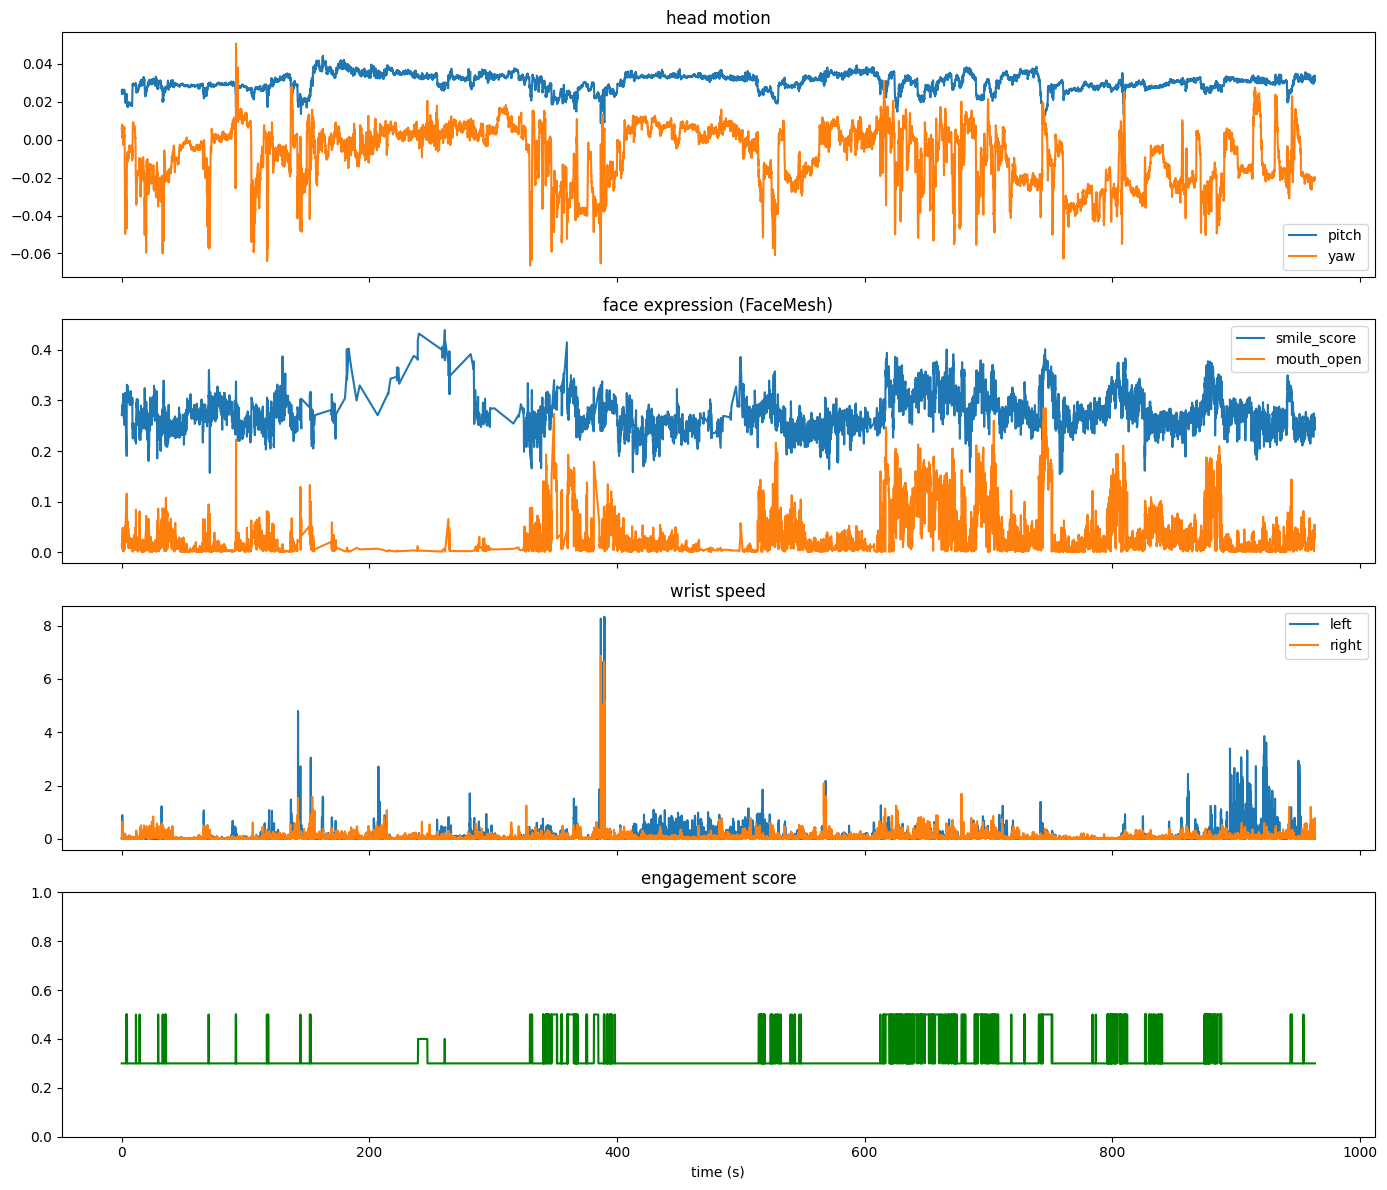

In [26]:
import matplotlib.pyplot as plt

result_files = sorted(OUTPUT_DIR.glob("*_features.csv"))
if result_files:
    df_check = pd.read_csv(result_files[0])
    print(result_files[0].name, f"— {len(df_check)} frames, {len(df_check.columns)} cols")

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    axes[0].plot(df_check["t"], df_check["pitch_proxy"], label="pitch")
    axes[0].plot(df_check["t"], df_check["yaw_proxy"],   label="yaw")
    axes[0].legend(); axes[0].set_title("head motion")

    axes[1].plot(df_check["t"], df_check["smile_score"],      label="smile_score")
    axes[1].plot(df_check["t"], df_check["mouth_open_score"], label="mouth_open")
    axes[1].legend(); axes[1].set_title("face expression (FaceMesh)")

    axes[2].plot(df_check["t"], df_check["left_wrist_speed"],  label="left")
    axes[2].plot(df_check["t"], df_check["right_wrist_speed"], label="right")
    axes[2].legend(); axes[2].set_title("wrist speed")

    axes[3].plot(df_check["t"], df_check["engagement_score"], color="green")
    axes[3].set_ylim(0, 1); axes[3].set_title("engagement score")
    axes[3].set_xlabel("time (s)")

    plt.tight_layout()
    plt.show()
